M1 Index

In [2]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, ConstraintList, Objective, SolverFactory, RangeSet, Binary

def compute_upper_bound_M1(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, n))

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(model.d[v]**2 for v in model.V), sense=1)

    # Define the constraint: sum of edges is equal to m
    model.edge_constraint = Constraint(expr=1/2*sum(model.x[u, v] for u in model.V for v in model.V) == m)

    # Define the constraints for vertex degrees
    model.degree_constraint = ConstraintList()
    for v in model.V:
        model.degree_constraint.add(expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v))
    
    # Constraint: sum of incident edges to vertex v is less than or equal to 4
    model.additional_constraint_3 = Constraint(expr=model.d[v] <= 4)  # Degree of other vertices is 2

    
    # Constraint: every vertex should be connected in a single graph
    model.single_graph_constraint = Constraint(expr=1/2*sum(model.x[u, v] for u in model.V for v in model.V if u != v) == m)

    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 6 # Number of vertices
m = 6 # Number of edges
upper_bound = compute_upper_bound_M1(n, m)
print("Upper bound for M1:", upper_bound)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

Upper bound for M1: 24.0
Process finished--- 1.326265811920166 seconds ---


In [3]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary

def compute_upper_bound_M1(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, 4), initialize=0)

    # Define the objective function to maximize the sum of squared degrees
    model.obj = Objective(expr=sum(model.d[v]**2 for v in model.V), sense=1)

    # Edge constraint: sum of edges must be exactly m
    model.edge_constraint = Constraint(expr=sum(0.5*model.x[u, v] for u in model.V for v in model.V if u != v) == m)
    # model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Degree constraint: for each vertex, its degree is the sum of incident edges
    model.degree_constraints = ConstraintList()
    for v in model.V:
        model.degree_constraints.add(expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v))
        #model.degree_constraints.add(expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v))

    # Relax degree constraints (remove or adjust if needed)
    for v in model.V:
        # Temporarily relax the degree constraint to see if it helps
        model.degree_constraints.add(expr=model.d[v] <= 4)  # Each vertex can connect to at most n-1 other vertices.

    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    result = solver.solve(model)

    # Check solver status and return the optimal objective value if the solution is valid
    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    if result.solver.status == 'ok' and result.solver.termination_condition == 'optimal':
        return model.obj()
    else:
        print(f"Solver did not find a feasible solution: {result.solver.status}")
        return None

# Example usage:
n = 4  # Number of vertices
m = 4  # Number of edges
start_time = time.time()

upper_bound = compute_upper_bound_M1(n, m)
print("Upper bound for M1:", upper_bound)
print("Process finished--- %s seconds ---" % (time.time() - start_time))

WARNING (W1001): Setting Var 'd[1]' to a value `0` (int) not in domain [1:4].
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1001
Vertex 1: Degree 2.0
Vertex 2: Degree 2.0
Vertex 3: Degree 2.0
Vertex 4: Degree 2.0
Upper bound for M1: 16.0
Process finished--- 0.1084299087524414 seconds ---


BQP

In [89]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, ConstraintList, Objective, SolverFactory, RangeSet, Binary

def compute_upper_bound_M1(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, n))

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(model.d[v]**2 for v in model.V), sense=-1)

    # Define the constraint: sum of edges is equal to m
    model.edge_constraint = Constraint(expr=sum(1/2*model.x[u, v] for u in model.V for v in model.V) == m)

    # Define the constraints for vertex degrees
    model.degree_constraint = ConstraintList()
    for v in model.V:
        model.degree_constraint.add(expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v))
        model.degree_constraint.add(expr=model.d[v] <= 4)
    # Constraint: sum of incident edges to vertex v is less than or equal to 4
    
    
    # Constraint: every vertex should be connected in a single graph
    model.single_graph_constraint = Constraint(expr=sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)


    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 62 # Number of vertices
m = 68 # Number of edges
upper_bound = compute_upper_bound_M1(n, m)
print("Upper bound for M1:", upper_bound)
print("Process finished--- %.4f seconds ---"% (time.time()-start_time))

Upper bound for M1: 430.0
Process finished--- 0.1834 seconds ---


Linear

In [232]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

def compute_upper_bound_M1_linear_program(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, 4))

    # Define binary decision variables y_{uv} for linearization
    model.y = Var(model.V, model.V, within=Binary)

    # Define the objective function to maximize
    model.obj = Objective(expr=sum((model.x[u, v] + 2*model.y[u, v]) for u in model.V for v in model.V if u != v), sense=1)

    # Define the constraint: sum of edges is equal to m
    model.edge_constraint = Constraint(expr=sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)

    # Define the constraints for linearization
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            if u != v:
                model.linearization_constraints.add(expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v))
                model.linearization_constraints.add(expr=sum(model.x[u, v] for u in model.V if u != v) <= 4)
                model.linearization_constraints.add(expr=sum(model.x[u, v] for u in model.V if u != v) >=1)
                model.linearization_constraints.add(model.y[u, v] <= model.x[u, v])
                model.linearization_constraints.add(model.y[u, v] <= model.x[v, u])
                model.linearization_constraints.add(model.y[u, v] >= model.x[u, v] + model.x[v, u] - 1)

#                for u_prime in model.V:
#                    for v_prime in model.V:
#                       if u_prime != v_prime and (u, v) != (u_prime, v_prime):
#                            model.linearization_constraints.add(model.y[u, v] <= model.x[u_prime, v_prime])
#                            model.linearization_constraints.add(model.y[u, v] <= model.x[v_prime, u_prime])
#                            model.linearization_constraints.add(model.y[u, v] >= model.x[u_prime, v_prime] + model.x[v_prime, u_prime] - 1)
    

    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.solve(model)

    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    for u in model.V:
        for v in model.V:
            print(f"Edge {u,v}: {model.x[u, v].value}")
            print(f"y {u,v}: {model.y[u, v].value}")

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 6 # Number of vertices
m = 6 # Number of edges
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)
print("Upper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

Vertex 1: Degree 1.0
Vertex 2: Degree 1.0
Vertex 3: Degree 2.0
Vertex 4: Degree 3.0
Vertex 5: Degree 1.0
Vertex 6: Degree 4.0
Edge (1, 1): None
y (1, 1): None
Edge (1, 2): 0.0
y (1, 2): -0.0
Edge (1, 3): 1.0
y (1, 3): -0.0
Edge (1, 4): 1.0
y (1, 4): -0.0
Edge (1, 5): 1.0
y (1, 5): -0.0
Edge (1, 6): 1.0
y (1, 6): -0.0
Edge (2, 1): 1.0
y (2, 1): 0.0
Edge (2, 2): None
y (2, 2): None
Edge (2, 3): -0.0
y (2, 3): -0.0
Edge (2, 4): 1.0
y (2, 4): -0.0
Edge (2, 5): 0.0
y (2, 5): -0.0
Edge (2, 6): 1.0
y (2, 6): -0.0
Edge (3, 1): -0.0
y (3, 1): 0.0
Edge (3, 2): -0.0
y (3, 2): 0.0
Edge (3, 3): None
y (3, 3): None
Edge (3, 4): -0.0
y (3, 4): -0.0
Edge (3, 5): -0.0
y (3, 5): -0.0
Edge (3, 6): 1.0
y (3, 6): -0.0
Edge (4, 1): -0.0
y (4, 1): 0.0
Edge (4, 2): 0.0
y (4, 2): 0.0
Edge (4, 3): 1.0
y (4, 3): 0.0
Edge (4, 4): None
y (4, 4): None
Edge (4, 5): -0.0
y (4, 5): -0.0
Edge (4, 6): -0.0
y (4, 6): -0.0
Edge (5, 1): -0.0
y (5, 1): 0.0
Edge (5, 2): 1.0
y (5, 2): 0.0
Edge (5, 3): -0.0
y (5, 3): 0.0
Edge 

Linear-fixed

In [144]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

def compute_upper_bound_M1_linear_program(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, 4))

    # Define binary decision variables y_{uv} for linearization
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Define the objective function to maximize
    #model.obj = Objective(expr=sum((model.x[u, v] + 2*model.y[u, v, u_prime, v_prime]) for u in model.V for v in model.V if u != v, for u_prime in model.V, for v_prime in model.V if u_prime != v_prime), sense=1)

    # Define the objective function to maximize
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u != v)  # Avoid double-counting
        + 2 * sum(model.y[u, v, u_prime, v_prime] 
                  for u in model.V for v in model.V 
                  for u_prime in model.V for v_prime in model.V 
                  if u_prime != v_prime),
        sense=1
    )

    # Define the constraint: sum of edges is equal to m
    model.edge_constraint = Constraint(expr=sum(0.5*model.x[u, v] for u in model.V for v in model.V if u != v) == m)

    # Define the constraints for linearization
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            if u != v:
                model.linearization_constraints.add(expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v))
                model.linearization_constraints.add(expr=sum(model.x[u, v] for u in model.V if u != v) <= 4)
#               model.linearization_constraints.add(model.y[u, v] <= model.x[u, v])
#                model.linearization_constraints.add(model.y[u, v] <= model.x[v, u])
#               model.linearization_constraints.add(model.y[u, v] >= model.x[u, v] + model.x[v, u] - 1)
                # Additional constraint for y_{uv} = x_{uv}x_{u'v'}
                for u_prime in model.V:
                    for v_prime in model.V:
                        if u_prime != v_prime and (u, v) != (u_prime, v_prime):
                            model.linearization_constraints.add(model.y[u, v, u_prime, v_prime] <= model.x[u, v]+model.x[u_prime, v_prime]-1)
#                            model.linearization_constraints.add(model.y[u, v] <= model.x[v_prime, u_prime])
#                            model.linearization_constraints.add(model.y[u, v] >= model.x[u_prime, v_prime] + model.x[v_prime, u_prime] - 1)

    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.solve(model)

    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 6 # Number of vertices
m = 6 # Number of edges
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)
print("Upper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
Vertex 1: Degree None
Vertex 2: Degree None
Vertex 3: Degree None
Vertex 4: Degree None
Vertex 5: Degree None
Vertex 6: Degree None
ERROR: evaluating object as numeric value: x[1,2]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized NumericValue object x[1,2]


ValueError: No value for uninitialized NumericValue object x[1,2]

In [215]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables for linearization (one per common starting vertex)
    model.y = Var(model.V, model.V, model.V, within=Binary)  # y(u, v, w)

    # Objective function
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
             sum(model.y[u, v, w] for u in model.V for v in model.V for w in model.V if v < w),
        sense=1
    )
    
    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v)
        ))

    model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (one y per common vertex)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for w in model.V:
                if v < w:  # Ensure pairs are counted once
                    model.linearization_constraints.add(
                        model.y[u, v, w] <= model.x[u, v]
                    )
                    model.linearization_constraints.add(
                        model.y[u, v, w] <= model.x[u, w]
                    )
                    model.linearization_constraints.add(
                        model.y[u, v, w] >= model.x[u, v] + model.x[u, w] - 1
                    )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nRaw Degree Values:")
    for v in model.V:
         print(f"Vertex {v}: Degree Variable = {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v:
                print(f"x({u}, {v}) = {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1:")
    for u in model.V:
        for v in model.V:
            for w in model.V:
                if v < w and model.y[u, v, w].value == 1:
                    print(f"y({u}, {v}, {w}) = 1")

    return model.obj()

# Run the model
n = 3
m = 3
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))



Raw Degree Values:
Vertex 1: Degree Variable = 2.0
Vertex 2: Degree Variable = 2.0
Vertex 3: Degree Variable = 2.0

Edges (x values):
x(1, 2) = 1.0
x(1, 3) = 1.0
x(2, 3) = 1.0

Linearization Variables (y values) where y = 1:
y(1, 2, 3) = 1

Upper bound for M1 (Linear Program): 4.0
Process finished --- 0.11051034927368164 seconds ---


In [222]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables for linearization (4 indices: u, v, u_prime, v_prime)
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function
    model.obj = Objective(
        expr=2*sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
             sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V 
                 for u_prime in model.V for v_prime in model.V if u < v and u_prime < v_prime),
        sense=1
    )
    
    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v)
        ))

    model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (only for shared vertex edges)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if u != v and u_prime != v_prime:  # Ensure the edges are different
                        # Ensure edges share vertex 2
                        if 2 in [u, v] or 2 in [u_prime, v_prime]:  # Shared vertex is 2
                            model.linearization_constraints.add(
                                model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                            )
                            model.linearization_constraints.add(
                                model.y[u, v, u_prime, v_prime] <= model.x[u_prime, v_prime]
                            )
                            model.linearization_constraints.add(
                                model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u_prime, v_prime] - 1
                            )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nRaw Degree Values:")
    for v in model.V:
        print(f"Vertex {v}: Degree Variable = {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v:
                print(f"x({u}, {v}) = {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1:")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if u != v and u_prime != v_prime:
                        # Ensure that y only activates when one of the edges shares vertex 2
                        if 2 in [u, v] or 2 in [u_prime, v_prime] and model.y[u, v, u_prime, v_prime].value == 1:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = 1")

    print("\nAll Linearization Variables (y values):")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if u != v and u_prime != v_prime:
                        if 2 in [u, v] or 2 in [u_prime, v_prime]:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = {model.y[u, v, u_prime, v_prime].value}")

    return model.obj()

# Run the model
n = 3
m = 3
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))



Raw Degree Values:
Vertex 1: Degree Variable = 2.0
Vertex 2: Degree Variable = 2.0
Vertex 3: Degree Variable = 2.0

Edges (x values):
x(1, 2) = 1.0
x(1, 3) = 1.0
x(2, 3) = 1.0

Linearization Variables (y values) where y = 1:
y(1, 2, 1, 2) = 1
y(1, 2, 1, 3) = 1
y(1, 2, 2, 1) = 1
y(1, 2, 2, 3) = 1
y(1, 2, 3, 1) = 1
y(1, 2, 3, 2) = 1
y(1, 3, 1, 2) = 1
y(1, 3, 2, 3) = 1
y(2, 1, 1, 2) = 1
y(2, 1, 1, 3) = 1
y(2, 1, 2, 1) = 1
y(2, 1, 2, 3) = 1
y(2, 1, 3, 1) = 1
y(2, 1, 3, 2) = 1
y(2, 3, 1, 2) = 1
y(2, 3, 1, 3) = 1
y(2, 3, 2, 1) = 1
y(2, 3, 2, 3) = 1
y(2, 3, 3, 1) = 1
y(2, 3, 3, 2) = 1
y(3, 2, 1, 2) = 1
y(3, 2, 1, 3) = 1
y(3, 2, 2, 1) = 1
y(3, 2, 2, 3) = 1
y(3, 2, 3, 1) = 1
y(3, 2, 3, 2) = 1

All Linearization Variables (y values):
y(1, 2, 1, 2) = 1.0
y(1, 2, 1, 3) = 1.0
y(1, 2, 2, 1) = 0.0
y(1, 2, 2, 3) = 1.0
y(1, 2, 3, 1) = 0.0
y(1, 2, 3, 2) = 0.0
y(1, 3, 1, 2) = 1.0
y(1, 3, 2, 1) = 0.0
y(1, 3, 2, 3) = 1.0
y(1, 3, 3, 2) = 0.0
y(2, 1, 1, 2) = 0.0
y(2, 1, 1, 3) = 0.0
y(2, 1, 2, 1) = 0.0
y(2, 

In [1]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables for linearization (4 indices: u, v, u_prime, v_prime)
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function 
    model.obj = Objective(
    expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
         sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V 
                 for u_prime in model.V for v_prime in model.V if u < v and u_prime < v_prime),
    sense=-1  # Maximization
)
          
    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v)
        ))

    model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (only for shared vertex edges)
    # Define the ConstraintList before adding constraints
    model.linearization_constraints = ConstraintList()

    # Ensure y is only defined for edges that share a vertex
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    # Ensure that (u, v) and (u', v') share at least one vertex
                    if (u == u_prime or u == v_prime or v == u_prime or v == v_prime) and (u != v and u_prime != v_prime):
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u_prime, v_prime]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u_prime, v_prime] - 1
                        )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nRaw Degree Values:")
    for v in model.V:
        print(f"Vertex {v}: Degree Variable = {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v:
                print(f"x({u}, {v}) = {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1:")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    # Ensure that the edges share a common vertex (either u == u_prime or v == v_prime)
                    if u != v and u_prime != v_prime:
                        if model.x[u, v].value == 1 and model.x[u_prime, v_prime].value == 1:
                            if u == u_prime or v == v_prime:  # Ensure they share a vertex
                                print(f"y({u}, {v}, {u_prime}, {v_prime}) = 1")

    print("\nAll Linearization Variables (y values):")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if u != v and u_prime != v_prime:
                        if model.x[u, v].value == 1 and model.x[u_prime, v_prime].value == 1:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = {model.y[u, v, u_prime, v_prime].value}")

    return model.obj()

# Run the model
n = 50
m = 53
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))


MILP FORMULATION

In [1]:
from pyomo.environ import (
    ConcreteModel, Var, Constraint, Objective, SolverFactory,
    RangeSet, Binary, NonNegativeReals, ConstraintList, maximize
)
import time

def compute_upper_bound_M1_linear_program(n, m):
    start_time = time.time()
    
    model = ConcreteModel()
    model.V = RangeSet(1, n)

    # Binary decision variables for edges (u < v only)
    model.x = Var(model.V, model.V, domain=Binary)

    # Degree variables and one-hot binary encodings for degree values 0-4
    model.d = Var(model.V, domain=NonNegativeReals)
    model.b = Var(model.V, RangeSet(0, 4), domain=Binary)  # degree indicator variables
    model.d_sq = Var(model.V, domain=NonNegativeReals)    # d^2 variables

    # Edge symmetry constraint: only use u < v
    def upper_triangular_edges(u, v):
        return u < v

    # Edge count constraint (total number of edges == m)
    model.edge_constraint = Constraint(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if upper_triangular_edges(u, v)) == m
    )

    # Connectivity constraint: every node must be connected to at least one edge
    for v in model.V:
        model.add_component(
            f"connectivity_{v}",
            Constraint(expr=sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v) >= 1)
        )

    # Degree definition: d[v] = sum of incident edges
    for v in model.V:
        model.add_component(
            f"degree_{v}",
            Constraint(expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v))
        )

    # One-hot degree encoding: exactly one degree value is active
    for v in model.V:
        model.add_component(
            f"degree_one_hot_{v}",
            Constraint(expr=sum(model.b[v, i] for i in range(5)) == 1)
        )

    # Link degree variable to one-hot encoding
    for v in model.V:
        model.add_component(
            f"degree_value_match_{v}",
            Constraint(expr=model.d[v] == sum(i * model.b[v, i] for i in range(5)))
        )

    # Define d^2 using indicator variables
    for v in model.V:
        model.add_component(
            f"degree_square_{v}",
            Constraint(expr=model.d_sq[v] == sum(i**2 * model.b[v, i] for i in range(5)))
        )

    # Objective: maximize sum of squared degrees
    model.obj = Objective(expr=sum(model.d_sq[v] for v in model.V), sense=-1)

    # Solve the model
    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print raw degree values and their squares
    print("\nVertex Degree and Degree^2:")
    for v in model.V:
        print(f"Vertex {v}: Degree = {model.d[v].value}, Degree^2 = {model.d_sq[v].value}")

    M1_upper_bound = sum(model.d_sq[v].value for v in model.V)
    print(f"\nUpper bound for M1 (Linear Program): {M1_upper_bound}")
    print("Process finished --- %.4f seconds ---" % (time.time() - start_time))
    
    return M1_upper_bound


In [2]:
n = 29
m = 31
compute_upper_bound_M1_linear_program(n, m)


ERROR: Solver (gurobi) returned non-zero return code (1)
ERROR: Solver log: Set parameter Username Traceback (most recent call last):
      File "<stdin>", line 5, in <module> File
      "c:\Users\betsie_0410\AppData\Local\anaconda3\envs\energiaenv\Lib\site-
      packages\pyomo\solvers\plugins\solvers\GUROBI_RUN.py", line 66, in
      gurobi_run
        model = read(model_file)
                ^^^^^^^^^^^^^^^^
      File "src\\gurobipy\\gurobi.pxi", line 3779, in gurobipy.read File
      "src\\gurobipy\\gurobi.pxi", line 112, in gurobipy.gurobi.read File
      "src\\gurobipy\\gurobi.pxi", line 60, in gurobipy.gurobi._getdefaultenv
      File "src\\gurobipy\\env.pxi", line 70, in gurobipy.Env.__init__
    gurobipy.GurobiError: License expired 2025-05-28


ApplicationError: Solver (gurobi) did not exit normally

In [2]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables for linearization (4 indices: u, v, u_prime, v_prime)
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
             sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V 
                 for u_prime in model.V for v_prime in model.V if u < v and u_prime < v_prime),
        sense=-1
    )
    
    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[min(u, v), max(u, v)] for u in model.V if u != v)
        ))

    model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (only for shared vertex edges)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime):  # Exclude identical edges
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v_prime]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u, v_prime] - 1
                        )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nRaw Degree Values:")
    for v in model.V:
        print(f"Vertex {v}: Degree Variable = {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v:
                print(f"x({u}, {v}) = {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1:")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime) and (u, v) != (u_prime, v_prime):
                        if model.y[u, v, u_prime, v_prime].value == 1:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = 1")

    print("\nAll Linearization Variables (y values):")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime):
                        print(f"y({u}, {v}, {u_prime}, {v_prime}) = {model.y[u, v, u_prime, v_prime].value}")

    return model.obj()

# Run the model
n = 22
m = 23
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))


In [244]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Degree variables bounded between 0 and 4
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables only for products from the same vertex
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function (counting y-products distinctly)
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
             2 * sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V
                     for u_prime in model.V for v_prime in model.V
                     if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime)),
        sense=1
    )

    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[u, v] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v)
        ))
        model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))  # Enforce max degree

    # McCormick inequalities for linearization (now counting y-products distinctly)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime):  # Same vertex but distinct edges
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u_prime, v_prime]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u_prime, v_prime] - 1
                        )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nVertex Degrees:")
    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v and model.x[u, v].value == 1:
                print(f"Edge ({u}, {v}): {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1 (counting distinct orders):")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if ((u == u_prime) or (v == v_prime)) and (u < v and u_prime < v_prime):
                        if model.y[u, v, u_prime, v_prime].value == 1:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = 1")

    return model.obj()

n = 22
m = 23
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))


In [173]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables only for products from the same vertex
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
              sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V
                     for u_prime in model.V for v_prime in model.V
                     if (u != u_prime or v != v_prime) and (u < v and u_prime < v_prime) and not (u == v or u_prime == v_prime)),
        sense=1
    )

    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[u, v] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v)
        ))
        model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (only for shared vertex edges)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if (u != u_prime or v != v_prime) and (u < v and u_prime < v_prime) and not (u == v or u_prime == v_prime):
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u_prime, v_prime]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u_prime, v_prime] - 1
                        )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nVertex Degrees:")
    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v and model.x[u, v].value == 1:
                print(f"Edge ({u}, {v}): {model.x[u, v].value}")

    print("\nLinearization Variables (y values) where y = 1:")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if (u != u_prime or v != v_prime) and (u < v and u_prime < v_prime) and not (u == v or u_prime == v_prime):
                        if model.y[u, v, u_prime, v_prime].value == 1:
                            print(f"y({u}, {v}, {u_prime}, {v_prime}) = 1")

    return model.obj()

n = 6
m = 6
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))



Vertex Degrees:
Vertex 1: Degree 4.0
Vertex 2: Degree 4.0
Vertex 3: Degree 1.0
Vertex 4: Degree 3.0
Vertex 5: Degree 2.0
Vertex 6: Degree 1.0

Edges (x values):
Edge (1, 2): 1.0
Edge (1, 4): 1.0
Edge (2, 5): 1.0
Edge (3, 4): 1.0
Edge (3, 5): 1.0
Edge (5, 6): 1.0

Linearization Variables (y values) where y = 1:
y(1, 2, 1, 4) = 1
y(1, 2, 2, 5) = 1
y(1, 2, 3, 4) = 1
y(1, 2, 3, 5) = 1
y(1, 2, 5, 6) = 1
y(1, 4, 1, 2) = 1
y(1, 4, 2, 5) = 1
y(1, 4, 3, 4) = 1
y(1, 4, 3, 5) = 1
y(1, 4, 5, 6) = 1
y(2, 5, 1, 2) = 1
y(2, 5, 1, 4) = 1
y(2, 5, 3, 4) = 1
y(2, 5, 3, 5) = 1
y(2, 5, 5, 6) = 1
y(3, 4, 1, 2) = 1
y(3, 4, 1, 4) = 1
y(3, 4, 2, 5) = 1
y(3, 4, 3, 5) = 1
y(3, 4, 5, 6) = 1
y(3, 5, 1, 2) = 1
y(3, 5, 1, 4) = 1
y(3, 5, 2, 5) = 1
y(3, 5, 3, 4) = 1
y(3, 5, 5, 6) = 1
y(5, 6, 1, 2) = 1
y(5, 6, 1, 4) = 1
y(5, 6, 2, 5) = 1
y(5, 6, 3, 4) = 1
y(5, 6, 3, 5) = 1

Upper bound for M1 (Linear Program): 36.0
Process finished --- 0.15933012962341309 seconds ---


In [166]:
import time
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

start_time = time.time()

def compute_upper_bound_M1_linear_program(n, m):
    model = ConcreteModel()

    model.V = RangeSet(1, n)

    # Binary decision variables for edges
    model.x = Var(model.V, model.V, within=Binary)

    # Allow degrees to be zero (avoiding infeasibility)
    model.d = Var(model.V, within=RangeSet(0, 4))

    # Binary decision variables only for products from the same vertex
    model.y = Var(model.V, model.V, model.V, model.V, within=Binary)

    # Objective function
    model.obj = Objective(
        expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) +
              2*sum(model.y[u, v, u_prime, v_prime] for u in model.V for v in model.V 
                     for u_prime in model.V for v_prime in model.V 
                     if (u == u_prime or v == v_prime) and (u < v and u_prime < v_prime)),
        sense=-1
    )

    # Total edge constraint
    model.edge_constraint = Constraint(expr=sum(model.x[u, v] for u in model.V for v in model.V if u < v) == m)

    # Connectivity constraint (ensures no isolated vertices)
    for v in model.V:
        model.add_component(f"connectivity_{v}", Constraint(
            expr=sum(model.x[u, v] for u in model.V if u != v) >= 1
        ))

    # Degree constraints
    for v in model.V:
        model.add_component(f"degree_{v}", Constraint(
            expr=model.d[v] == sum(model.x[u, v] for u in model.V if u != v)
        ))
        model.add_component(f"degree_upper_bound_{v}", Constraint(expr=model.d[v] <= 4))

    # McCormick inequalities for linearization (only for shared vertex edges)
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if (u != u_prime or v != v_prime):  # Ensure that (u, v) != (u', v')
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u, v]
                        )
                        model.linearization_constraints.add(
                            model.y[u, v, u_prime, v_prime] <= model.x[u_prime, v_prime]
                        )
                        model.linearization_constraints.add(
                         model.y[u, v, u_prime, v_prime] >= model.x[u, v] + model.x[u_prime, v_prime] - 1
                        )

    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Print results
    print("\nVertex Degrees:")
    for v in model.V:
        print(f"Vertex {v}: Degree {model.d[v].value}")

    print("\nEdges (x values):")
    for u in model.V:
        for v in model.V:
            if u < v:
                print(f"Edge ({u}, {v}): {model.x[u, v].value}")

    print("\nLinearization Variables (y values):")
    for u in model.V:
        for v in model.V:
            for u_prime in model.V:
                for v_prime in model.V:
                    if (u == u_prime or v == v_prime) and u < v and u_prime < v_prime:
                        print(f"y({u}, {v}, {u_prime}, {v_prime}): {model.y[u, v, u_prime, v_prime].value}")

    return model.obj()

n = 6  
m = 6  
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)

print("\nUpper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Process finished --- %s seconds ---" % (time.time() - start_time))



Vertex Degrees:
Vertex 1: Degree 4.0
Vertex 2: Degree 4.0
Vertex 3: Degree 3.0
Vertex 4: Degree 2.0
Vertex 5: Degree 1.0
Vertex 6: Degree 1.0

Edges (x values):
Edge (1, 2): 1.0
Edge (1, 3): 1.0
Edge (1, 4): 1.0
Edge (1, 5): 1.0
Edge (1, 6): 1.0
Edge (2, 3): 1.0
Edge (2, 4): 0.0
Edge (2, 5): 0.0
Edge (2, 6): 0.0
Edge (3, 4): 0.0
Edge (3, 5): 0.0
Edge (3, 6): 0.0
Edge (4, 5): 0.0
Edge (4, 6): 0.0
Edge (5, 6): 0.0

Linearization Variables (y values):
y(1, 2, 1, 2): 1.0
y(1, 2, 1, 3): 1.0
y(1, 2, 1, 4): 1.0
y(1, 2, 1, 5): 1.0
y(1, 2, 1, 6): 1.0
y(1, 3, 1, 2): 1.0
y(1, 3, 1, 3): 1.0
y(1, 3, 1, 4): 1.0
y(1, 3, 1, 5): 1.0
y(1, 3, 1, 6): 1.0
y(1, 3, 2, 3): 1.0
y(1, 4, 1, 2): 1.0
y(1, 4, 1, 3): 1.0
y(1, 4, 1, 4): 1.0
y(1, 4, 1, 5): 1.0
y(1, 4, 1, 6): 1.0
y(1, 4, 2, 4): 0.0
y(1, 4, 3, 4): 0.0
y(1, 5, 1, 2): 1.0
y(1, 5, 1, 3): 1.0
y(1, 5, 1, 4): 1.0
y(1, 5, 1, 5): 1.0
y(1, 5, 1, 6): 1.0
y(1, 5, 2, 5): 0.0
y(1, 5, 3, 5): 0.0
y(1, 5, 4, 5): 0.0
y(1, 6, 1, 2): 1.0
y(1, 6, 1, 3): 1.0
y(1, 6, 1, 4):

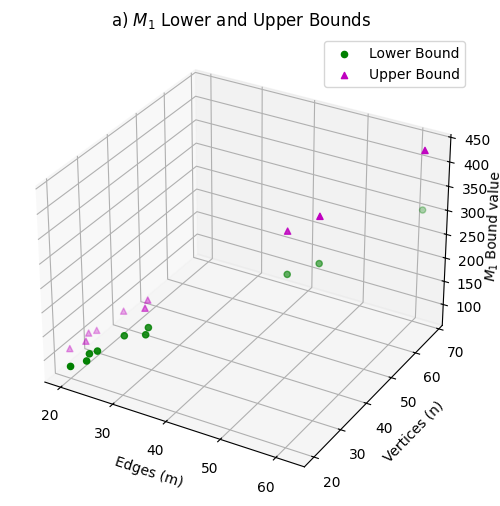

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data: (m, n) pairs and their corresponding lower bounds for BQF and LF
data = [
    ((22, 23), (98, 142)),  # (m, n), (BQF lower bound, LF lower bound)
    ((23, 24), (102, 146)),  
    ((46, 49), (214, 304)),
    ((50, 53), (230, 328)),
    ((26, 28), (124, 176)),
    ((29, 30), (126, 182)),
    ((20, 20), (80, 118)),
    ((29, 31), (136, 194)),
    ((62, 68), (308, 430)),
    ((22, 22), (88, 130))
]

# Extracting m, n, BQF lower bound, and LF lower bound values
m_values = [pair[0] for pair, _ in data]
n_values = [pair[1] for pair, _ in data]
bqf_lower_bounds = [bounds[0] for _, bounds in data]
lf_lower_bounds = [bounds[1] for _, bounds in data]

# Create a 3D plot with expanded size
fig = plt.figure(figsize=(12, 6))  # Adjust the size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot BQF lower bounds
ax.scatter(m_values, n_values, bqf_lower_bounds, c='g', marker='o', label='Lower Bound')

# Plot LF lower bounds
ax.scatter(m_values, n_values, lf_lower_bounds, c='m', marker='^', label='Upper Bound')

# Set labels and title
ax.set_xlabel('Edges (m)')
ax.set_ylabel('Vertices (n)')
ax.set_zlabel('$M_1$ Bound value', labelpad=-0.1)
ax.set_title('a) $M_1$ Lower and Upper Bounds')
ax.legend()
ax.dist = 12

plt.subplots_adjust(right=5)
plt.subplots_adjust(left=0.10, right=10)  # Shift plot to the left and make room on the right

# Show plot
plt.show()


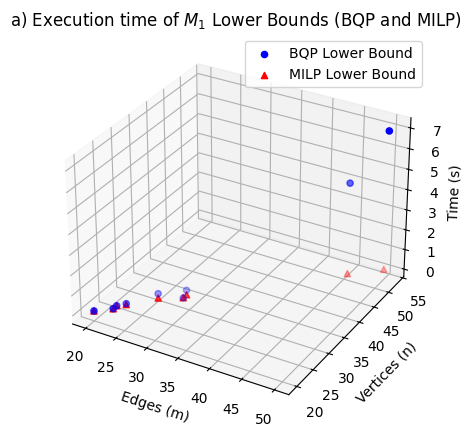

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data: (m, n) pairs and their corresponding lower bounds for BQF and MILP
data = [
    ((22, 23), (0.1093, 0.1090)),
    ((23, 24), (0.1566, 0.1125)),
    ((46, 49), (4.6567, 0.1330)),
    ((50, 53), (6.9835, 0.1368)),
    ((26, 28), (0.3445, 0.1216)),
    ((29, 30), (0.1165, 0.1276)),
    ((20, 20), (0.1097, 0.1088)),
    ((29, 31), (0.3546, 0.1239)),
    ((22, 22), (0.1107, 0.1077))
]

# Extracting m, n, BQF lower bound, and LF lower bound values
m_values = [pair[0] for pair, _ in data]
n_values = [pair[1] for pair, _ in data]
bqf_lower_bounds = [bounds[0] for _, bounds in data]
lf_lower_bounds = [bounds[1] for _, bounds in data]

# Create a 3D plot with expanded size
fig = plt.figure(figsize=(10, 5))  # Adjust the size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot BQF lower bounds
ax.scatter(m_values, n_values, bqf_lower_bounds, c='b', marker='o', label='BQP Lower Bound')

# Plot LF lower bounds
ax.scatter(m_values, n_values, lf_lower_bounds, c='r', marker='^', label='MILP Lower Bound')

# Set labels and title
ax.set_xlabel('Edges (m)')
ax.set_ylabel('Vertices (n)')
ax.set_zlabel('Time (s)', labelpad=0)
ax.set_title('a) Execution time of $M_1$ Lower Bounds (BQP and MILP)')
ax.legend()
ax.dist = 12

# Show plot
plt.show()

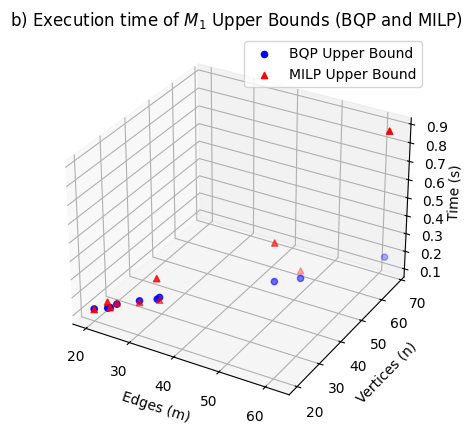

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data: (m, n) pairs and their corresponding lower bounds for BQF and LF
data= [
    ((22, 23), (0.1100, 0.1098)),
    ((23, 24), (0.1253, 0.1314)),
    ((46, 49), (0.1395, 0.3557)),
    ((50, 53), (0.1422, 0.1845)),
    ((26, 28), (0.1202, 0.1110)),
    ((29, 30), (0.1295, 0.2446)),
    ((20, 20), (0.1214, 0.1185)),
    ((29, 31), (0.1279, 0.1119)),
    ((22, 22), (0.1188, 0.1523)),
    ((62, 68), (0.1834, 0.8771))
]

# Extracting m, n, BQF lower bound, and LF lower bound values
m_values = [pair[0] for pair, _ in data]
n_values = [pair[1] for pair, _ in data]
bqf_lower_bounds = [bounds[0] for _, bounds in data]
lf_lower_bounds = [bounds[1] for _, bounds in data]

# Create a 3D plot with expanded size
fig = plt.figure(figsize=(10, 5))  # Adjust the size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot BQF lower bounds
ax.scatter(m_values, n_values, bqf_lower_bounds, c='b', marker='o', label='BQP Upper Bound')

# Plot LF lower bounds
ax.scatter(m_values, n_values, lf_lower_bounds, c='r', marker='^', label='MILP Upper Bound')

# Set labels and title
ax.set_xlabel('Edges (m)')
ax.set_ylabel('Vertices (n)')
ax.set_zlabel('Time (s)', labelpad=0)
ax.set_title('b) Execution time of $M_1$ Upper Bounds (BQP and MILP)')
ax.legend()
ax.dist = 12


# Show plot
plt.show()

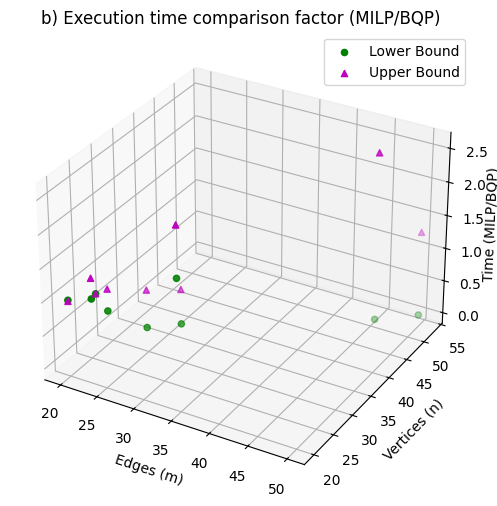

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data: (m, n) pairs and their corresponding lower bounds for BQF and LF
data = [
    ((22, 23), (0.9973, 0.9982)),
    ((23, 24), (0.7184, 1.0487)),
    ((46, 49), (0.0286, 2.5498)),
    ((50, 53), (0.0196, 1.2975)),
    ((26, 28), (0.3530, 0.9235)),
    ((29, 30), (1.0953, 1.8888)),
    ((20, 20), (0.9918, 0.9761)),
    ((29, 31), (0.3494, 0.8749)),
#    ((62, 68), (None, 4.7824)),
    ((22, 22), (0.9729, 1.2820))
]

# Extracting m, n, BQF lower bound, and LF lower bound values
m_values = [pair[0] for pair, _ in data]
n_values = [pair[1] for pair, _ in data]
error_lower_bounds = [bounds[0] for _, bounds in data]
error_upper_bounds = [bounds[1] for _, bounds in data]

# Create a 3D plot with expanded size
fig = plt.figure(figsize=(12, 6))  # Adjust the size as needed
ax = fig.add_subplot(111, projection='3d')

# Plot BQF lower bounds
ax.scatter(m_values, n_values, error_lower_bounds, c='g', marker='o', linestyle='-', label='Lower Bound')

# Plot LF lower bounds
ax.scatter(m_values, n_values, error_upper_bounds, c='m', marker='^', linestyle='-', label='Upper Bound')

# Set labels and title
ax.set_xlabel('Edges (m)')
ax.set_ylabel('Vertices (n)')
ax.set_zlabel('Time (MILP/BQP)', labelpad=-1)
ax.set_title('b) Execution time comparison factor (MILP/BQP)')
ax.legend()
ax.dist = 12

plt.subplots_adjust(right=5)
plt.subplots_adjust(left=0.10, right=10)  # Shift plot to the left and make room on the right

# Show plot
plt.grid(True)
plt.show()

In [32]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, ConstraintList

def compute_upper_bound_M1_linear_program(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define binary decision variables y_{uv} for linearization
    model.y = Var(model.V, model.V, within=Binary)

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(2*(model.x[u, v] + 2*model.y[u, v]) for u in model.V for v in model.V if u != v), sense=1)

    # Define the constraint: sum of edges is equal to m
    model.edge_constraint = Constraint(expr=sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)

    # Define the constraints for linearization
    model.linearization_constraints = ConstraintList()
    for u in model.V:
        for v in model.V:
            if u != v:
                model.linearization_constraints.add(model.y[u, v] <= model.x[u, v])
                model.linearization_constraints.add(model.y[u, v] <= model.x[v, u])
                model.linearization_constraints.add(model.y[u, v] >= model.x[u, v] + model.x[v, u] - 1)
                # Additional constraint for y_{uv} = x_{uv}x_{u'v'}
                for u_prime in model.V:
                    for v_prime in model.V:
                        if u_prime != v_prime and (u, v) != (u_prime, v_prime):
                            model.linearization_constraints.add(model.y[u, v] <= model.x[u_prime, v_prime])
                            model.linearization_constraints.add(model.y[u, v] <= model.x[v_prime, u_prime])
                            model.linearization_constraints.add(model.y[u, v] >= model.x[u_prime, v_prime] + model.x[v_prime, u_prime] - 1)

    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 22 # Number of vertices
m = 23 # Number of edges
upper_bound_linear_program = compute_upper_bound_M1_linear_program(n, m)
print("Upper bound for M1 (Linear Program):", upper_bound_linear_program)
print("Upper bound for M1:", upper_bound)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

Upper bound for M1 (Linear Program): 92.0
Upper bound for M1: 486.0
Process finished--- 48.094810962677 seconds ---


M2 Index


In [17]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, ConstraintList, Objective, SolverFactory, RangeSet, Binary, NonNegativeReals, Constraint

def compute_upper_bound_M2(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, n-1))

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define continuous decision variables y_{uv} for the quadratic term
    model.y = Var(model.V, model.V, within=NonNegativeReals)

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(1/2*model.y[u, v] for u in model.V for v in model.V if u != v), sense=-1)
    
    # Define constraints for quadratic term
    model.quadratic_constraint_1 = ConstraintList()
    model.quadratic_constraint_2 = ConstraintList()
    model.quadratic_constraint_3 = ConstraintList()
    model.quadratic_constraint_4 = ConstraintList()
    model.quadratic_constraint_5 = ConstraintList()
    model.quadratic_constraint_6 = ConstraintList()
    model.quadratic_constraint_7 = ConstraintList()
 
    for u in model.V:
        for v in model.V:
            if u != v:
                model.quadratic_constraint_1.add(expr= sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)
                model.quadratic_constraint_2.add(expr=model.d[v] - sum(model.x[u, v] for u in model.V if u != v) == 0)
                model.quadratic_constraint_3.add(expr=model.y[u, v] - (n-1)**2 * model.x[u, v] <= 0)
                model.quadratic_constraint_4.add(expr=model.y[u, v] - model.d[v]*model.d[u] <= 0)
                model.quadratic_constraint_5.add(expr=-model.y[u, v] + model.d[v]*model.d[u] + (n-1)**2 * model.x[u, v] <= (n-1)**2)
                model.quadratic_constraint_6.add(expr=model.d[v] <= 4)
                model.quadratic_constraint_7.add(expr=model.d[u] <= 4)


    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.options['NonConvex'] = 2  # Set NonConvex parameter to 2
    results = solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 5  # Number of vertices
m = 4  # Number of edges
upper_bound = compute_upper_bound_M2(n, m)
print("Upper bound for M2:", upper_bound)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

Upper bound for M2: 16.0
Process finished--- 0.7656316757202148 seconds ---


M2 Linearization


In [15]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, RangeSet, Binary, NonNegativeReals, ConstraintList

def compute_upper_bound_M2(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, n-1))

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define continuous decision variables y_{uv} for the quadratic term
    model.y = Var(model.V, model.V, within=NonNegativeReals)

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(1/2*model.y[u, v] for u in model.V for v in model.V if u != v), sense=1)

    # Define constraints for quadratic term
    model.quadratic_constraint_1 = ConstraintList()
    model.quadratic_constraint_2 = ConstraintList()
    model.quadratic_constraint_3 = ConstraintList()
    model.quadratic_constraint_4 = ConstraintList()
    model.quadratic_constraint_5 = ConstraintList()
    model.quadratic_constraint_6 = ConstraintList()


    for u in model.V:
        for v in model.V:
            if u != v:
                model.quadratic_constraint_1.add(expr=sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)
                model.quadratic_constraint_2.add(expr=model.y[u, v] - (n-1)**2 * model.x[u, v] <= 0)
                model.quadratic_constraint_3.add(expr=model.y[u, v] - sum(1/2*model.x[u_, v_] for u_ in model.V if u_ != v for v_ in model.V if v_ != u_) <= 0)
                model.quadratic_constraint_4.add(expr=-model.y[u, v] + sum(1/2*model.x[u_, v_] for u_ in model.V if u_ != v for v_ in model.V if v_ != u_) + (n-1)**2 * model.x[u, v] <= (n-1)**2)
                model.quadratic_constraint_5.add(expr=model.d[v] <= 4)
                model.quadratic_constraint_6.add(expr=model.d[u] <= 4)


    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    results = solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 5  # Number of vertices
m = 4
  # Number of edges
upper_bound = compute_upper_bound_M2(n, m)
print("Upper bound for M2:", upper_bound)
print("Process finished--- %s seconds ---"% (time.time()-start_time))


Upper bound for M2: 11.0
Process finished--- 0.597759485244751 seconds ---


In [ ]:
import time
start_time =time.time()
from pyomo.environ import ConcreteModel, Var, ConstraintList, Objective, SolverFactory, RangeSet, Binary, NonNegativeReals, Constraint

def compute_upper_bound_M2(n, m):
    # Create a concrete Pyomo model
    model = ConcreteModel()

    # Define the set of vertices
    model.V = RangeSet(1, n)

    # Define degree variables d_v for each vertex
    model.d = Var(model.V, within=RangeSet(1, n-1))

    # Define binary decision variables x_{uv} for each edge
    model.x = Var(model.V, model.V, within=Binary)

    # Define continuous decision variables y_{uv} for the quadratic term
    model.y = Var(model.V, model.V, within=NonNegativeReals)

    # Define the objective function to maximize
    model.obj = Objective(expr=sum(1/2*model.y[u, v] for u in model.V for v in model.V if u != v), sense=1)
    
    # Define constraints for quadratic term
    model.quadratic_constraint_1 = ConstraintList()
    model.quadratic_constraint_2 = ConstraintList()
    model.quadratic_constraint_3 = ConstraintList()
    model.quadratic_constraint_4 = ConstraintList()
    model.quadratic_constraint_5 = ConstraintList()
    model.quadratic_constraint_6 = ConstraintList()
 
    for u in model.V:
        for v in model.V:
            if u != v:
                model.quadratic_constraint_1.add(expr= sum(1/2*model.x[u, v] for u in model.V for v in model.V if u != v) == m)
                model.quadratic_constraint_2.add(expr=model.y[u, v] - (n-1)**2 * model.x[u, v] <= 0)
                model.quadratic_constraint_3.add(expr=model.y[u, v] - sum(model.x[u, v] for u in model.V if u != v for v in model.V if v != u ) <= 0)
                model.quadratic_constraint_4.add(expr=-model.y[u, v] + sum(model.x[u, v] for u in model.V if u != v for v in model.V if v != u ) + (n-1)**2 * model.x[u, v] <= (n-1)**2)
                model.quadratic_constraint_5.add(expr=model.d[v] <= 4)
                model.quadratic_constraint_6.add(expr=model.d[u] <= 4)


    # Solve the optimization problem
    solver = SolverFactory('gurobi')
    solver.options['NonConvex'] = 2  # Set NonConvex parameter to 2
    results = solver.solve(model)

    # Return the optimal objective value
    return model.obj()

# Example usage:
n = 5  # Number of vertices
m = 4  # Number of edges
upper_bound = compute_upper_bound_M2(n, m)
print("Upper bound for M2:", upper_bound)
print("Process finished--- %s seconds ---"% (time.time()-start_time))

In [1]:
pip install rdkit-pypi

   ---------------------------------------- 0.0/20.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/20.5 MB 991.0 kB/s eta 0:00:21
   - -------------------------------------- 0.8/20.5 MB 10.2 MB/s eta 0:00:02
   ---- ----------------------------------- 2.1/20.5 MB 16.6 MB/s eta 0:00:02
   ------ --------------------------------- 3.1/20.5 MB 20.1 MB/s eta 0:00:01
   --------- ------------------------------ 5.0/20.5 MB 22.8 MB/s eta 0:00:01
   ----------- ---------------------------- 6.0/20.5 MB 22.8 MB/s eta 0:00:01
   ------------ --------------------------- 6.3/20.5 MB 23.7 MB/s eta 0:00:01
   ------------ --------------------------- 6.3/20.5 MB 23.7 MB/s eta 0:00:01
   -------------- ------------------------- 7.3/20.5 MB 19.5 MB/s eta 0:00:01
   ---------------- ----------------------- 8.5/20.5 MB 18.8 MB/s eta 0:00:01
   ------------------ --------------------- 9.5/20.5 MB 18.9 MB/s eta 0:00:01
   ---------------------- ----------------- 11.4/20.5 MB 22.6 MB/s eta 

$ pip install networkx[default]


In [4]:
pip install networkx[default]


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
    --------------------------------------- 0.0/1.7 MB 1.4 MB/s eta 0:00:02
   ------ --------------------------------- 0.3/1.7 MB 4.3 MB/s eta 0:00:01
   ---------------- ----------------------- 0.7/1.7 MB 6.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.2/1.7 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  1.7/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 8.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Chemical representation & examples

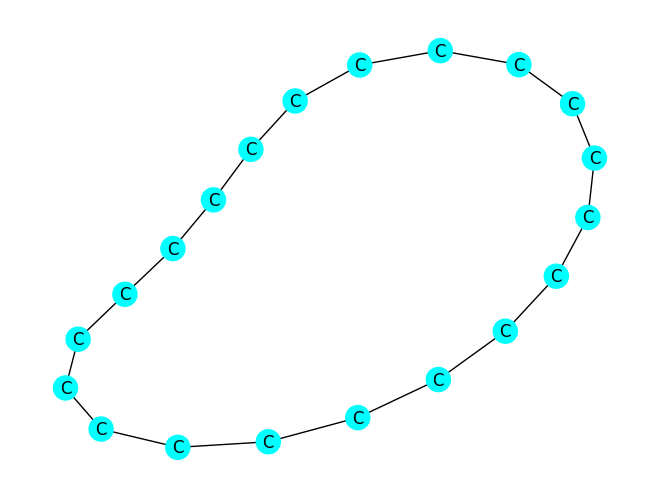

  (0, 1)	1
  (0, 19)	1
  (1, 0)	1
  (1, 2)	1
  (2, 1)	1
  (2, 3)	1
  (3, 2)	1
  (3, 4)	1
  (4, 3)	1
  (4, 5)	1
  (5, 4)	1
  (5, 6)	1
  (6, 5)	1
  (6, 7)	1
  (7, 6)	1
  (7, 8)	1
  (8, 7)	1
  (8, 9)	1
  (9, 8)	1
  (9, 10)	1
  (10, 9)	1
  (10, 11)	1
  (11, 10)	1
  (11, 12)	1
  (12, 11)	1
  (12, 13)	1
  (13, 12)	1
  (13, 14)	1
  (14, 13)	1
  (14, 15)	1
  (15, 14)	1
  (15, 16)	1
  (16, 15)	1
  (16, 17)	1
  (17, 16)	1
  (17, 18)	1
  (18, 17)	1
  (18, 19)	1
  (19, 0)	1
  (19, 18)	1


In [7]:

# import library --------------------------------------------------------------
from rdkit import Chem
import networkx as nx
import matplotlib.pyplot as plt

# define the smiles string and covert it into a molecule structure ------------
caffeine_smiles = "C1=C\C=C/C=C\C=C/C=C\C=C/C=C\C=C/C=C\C=C1"
# Example: COCCCC/C(=N\OCCN)/C1=CC=C(C=C1)C(F)(F)F
# Isobutane 'CC(C)C'
# Caffeine 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'  
# Kinase inhibitor "C1CC2=C3C(=CC=C2)C(=CN3C1)[C@H]4[C@@H](C(=O)NC4=O)C5=CNC6=CC=CC=C65"
# Buckminsterfullerene C1%13=C2C5=C7C%10=C1C%11=C%14C%15=C%29C%12=C%30C9=C%22C8=C%21C6=C%20C4=C%19C3=C%18C%16=C(C2=C3C4=C5C6=C7C8=C9C%10=C%11%12)C%13=C%14C%17=C%15C%28=C%26C(=C%16%17)C%18=C%25C%19=C%24C%20=C%21C%23=C%22C%31=C%27C%23=C%24C%25=C%26C%27=C%28C%29=C%30%31
# Another fullerene CN(C)CCN(C)CCOC(=O)CCCC1(C23C14C5=C6C7=C8C9=C1C%10=C%11C%12=C%13C%14=C%10C%10=C1C1=C%15C%16=C%17C%18=C%19C%20=C%21C%22=C%23C%24=C%25C%26=C(C7=C9C%11=C%26C%12=C%24C%22=C%13C%20=C%14C%18=C%10%16)C7=C%25C9=C(C4=C76)C4=C2C(=C%17C3=C%15C5=C81)C%19=C%21C4=C%239)C1=CC=CC=C1
# etoposide; 33419-42-0; VePesid; Toposar; trans-Etoposide "C[C@@H]1OC[C@@H]2[C@@H](O1)[C@@H]([C@H]([C@@H](O2)O[C@H]3[C@H]4COC(=O)[C@@H]4[C@@H](C5=CC6=C(C=C35)OCO6)C7=CC(=C(C(=C7)OC)O)OC)O)O"

#canonical smiles references: https://pubchem.ncbi.nlm.nih.gov/
#Chemical properties: https://www.chemspider.com/
caffeine_mol = Chem.MolFromSmiles(caffeine_smiles)

# define the function for coverting rdkit object to networkx object -----------     
def mol_to_nx(mol):
    G = nx.Graph()

    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(),
                   atomic_num=atom.GetAtomicNum(),
                   is_aromatic=atom.GetIsAromatic(),
                   atom_symbol=atom.GetSymbol())
        
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(),
                   bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType())
        
    return G

# conver rdkit object to networkx object --------------------------------------
caffeine_nx = mol_to_nx(caffeine_mol)

caffeine_atom = nx.get_node_attributes(caffeine_nx, 'atom_symbol')

color_map = {'C': 'cyan',
             'O': 'orange',
             'N': 'magenta'}  

caffeine_colors = []
for idx in caffeine_nx.nodes():
    if (caffeine_nx.nodes[idx]['atom_symbol'] in color_map):
        caffeine_colors.append(color_map[caffeine_nx.nodes[idx]['atom_symbol']])
    else:
        caffeine_colors.append('gray')
    
nx.draw(caffeine_nx,
        labels=caffeine_atom,
        with_labels = True,
        node_color=caffeine_colors,
        node_size=300)

plt.show()

# print out the adjacency matrix ---------------------------------------------- 
matrix =nx.adjacency_matrix(caffeine_nx)
print(matrix)

In [8]:
# print out the adjacency matrix ---------------------------------------------- 
matrix =nx.adjacency_matrix(caffeine_nx)
print(matrix)

  (0, 1)	1
  (0, 19)	1
  (1, 0)	1
  (1, 2)	1
  (2, 1)	1
  (2, 3)	1
  (3, 2)	1
  (3, 4)	1
  (4, 3)	1
  (4, 5)	1
  (5, 4)	1
  (5, 6)	1
  (6, 5)	1
  (6, 7)	1
  (7, 6)	1
  (7, 8)	1
  (8, 7)	1
  (8, 9)	1
  (9, 8)	1
  (9, 10)	1
  (10, 9)	1
  (10, 11)	1
  (11, 10)	1
  (11, 12)	1
  (12, 11)	1
  (12, 13)	1
  (13, 12)	1
  (13, 14)	1
  (14, 13)	1
  (14, 15)	1
  (15, 14)	1
  (15, 16)	1
  (16, 15)	1
  (16, 17)	1
  (17, 16)	1
  (17, 18)	1
  (18, 17)	1
  (18, 19)	1
  (19, 0)	1
  (19, 18)	1


In [9]:
# print out the adjacency matrix
matrix = nx.adjacency_matrix(caffeine_nx)
adjacency_matrix = print(matrix.toarray())

[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]]


In [10]:
# Get the adjacency matrix
matrix = nx.adjacency_matrix(caffeine_nx)

# Convert the sparse matrix to a dense matrix
adjacency_matrix = matrix.toarray()

# Initialize an empty set to store the edges
edges = set()

# Iterate over the rows and columns of the adjacency matrix
num_nodes = adjacency_matrix.shape[0]
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):  # Iterate over the upper triangular part
        if adjacency_matrix[i][j] != 0:
            edges.add((i, j))  # Add edge (i, j)

print("Set of edges:", edges)

Set of edges: {(3, 4), (12, 13), (8, 9), (17, 18), (13, 14), (18, 19), (4, 5), (5, 6), (14, 15), (0, 1), (9, 10), (1, 2), (10, 11), (0, 19), (6, 7), (15, 16), (2, 3), (11, 12), (7, 8), (16, 17)}


In [11]:
print(edges)

{(3, 4), (12, 13), (8, 9), (17, 18), (13, 14), (18, 19), (4, 5), (5, 6), (14, 15), (0, 1), (9, 10), (1, 2), (10, 11), (0, 19), (6, 7), (15, 16), (2, 3), (11, 12), (7, 8), (16, 17)}


In [12]:
def zagreb_index_1_from_edges(edges):
    # Step 1: Compute the degree of each vertex, excluding hydrogen atoms
    degrees = {}
    for u, v in edges:
        if 'H' not in caffeine_atom[u]:
            degrees[u] = degrees.get(u, 0) + 1
        if 'H' not in caffeine_atom[v]:
            degrees[v] = degrees.get(v, 0) + 1
    
    # Step 2: Calculate Zagreb index 1
    zagreb_index = sum(degree ** 2 for degree in degrees.values())
    
    return zagreb_index

index = zagreb_index_1_from_edges(edges)
print("Zagreb index 1:", index)

Zagreb index 1: 80


In [13]:
def zagreb_index_2_from_edges(edges):
    # Step 1: Compute the degree of each vertex, excluding hydrogen atoms
    degrees = {}
    for u, v in edges:
        if 'H' not in caffeine_atom[u]:
            degrees[u] = degrees.get(u, 0) + 1
        if 'H' not in caffeine_atom[v]:
            degrees[v] = degrees.get(v, 0) + 1
    
    # Step 2: Calculate Zagreb index 2
    zagreb_index = sum(degrees[u] * degrees[v] for u, v in edges)
    
    return zagreb_index

# Calculate Zagreb index 2 using the edges
index = zagreb_index_2_from_edges(edges)
print("Zagreb index 2:", index)

Zagreb index 2: 80


In [14]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
IPythonConsole.ipython_useSVG=True  #< set this to False if you want PNGs instead of SVGs

In [15]:
def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol

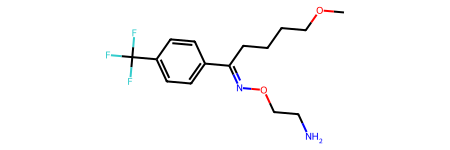

In [16]:
# Test in a kinase inhibitor
#mol = Chem.MolFromSmiles("C1CC2=C3C(=CC=C2)C(=CN3C1)[C@H]4[C@@H](C(=O)NC4=O)C5=CNC6=CC=CC=C65")
mol = Chem.MolFromSmiles("COCCCC/C(=N\OCCN)/C1=CC=C(C=C1)C(F)(F)F")
# Default
mol

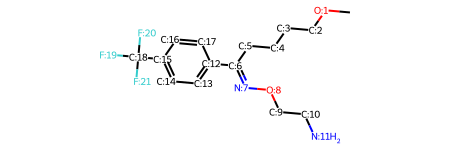

In [17]:
# With atom index
mol_with_atom_index(mol)

In [18]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300

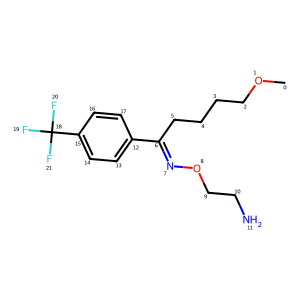

In [19]:
mol = Chem.MolFromSmiles("COCCCC/C(=N\OCCN)/C1=CC=C(C=C1)C(F)(F)F")
mol

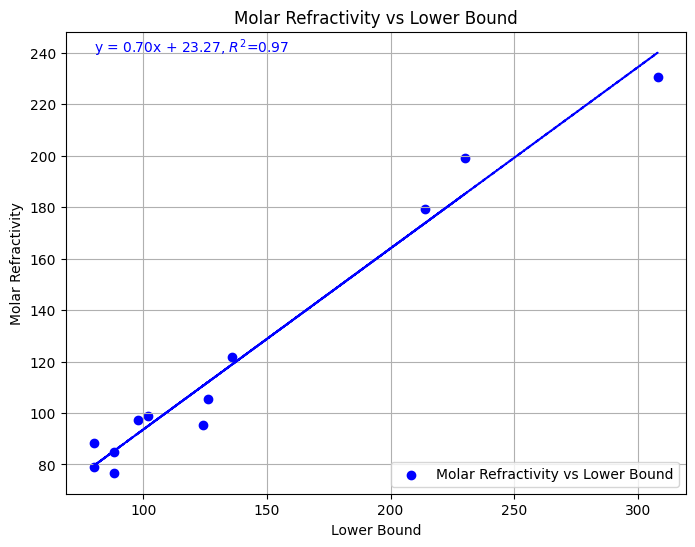

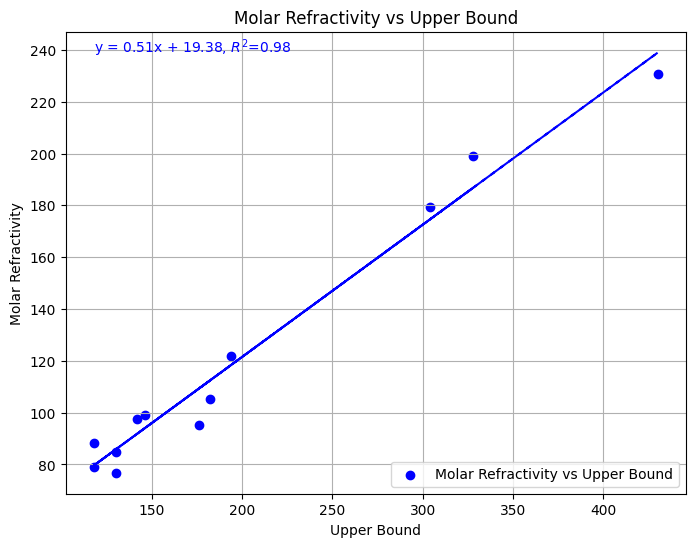

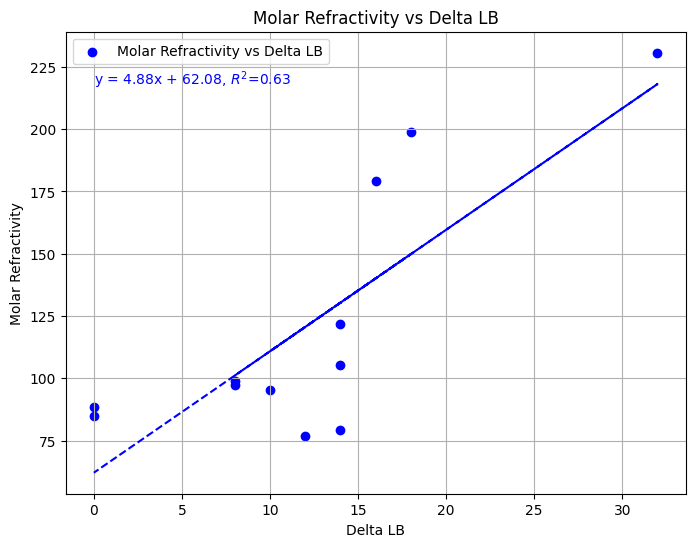

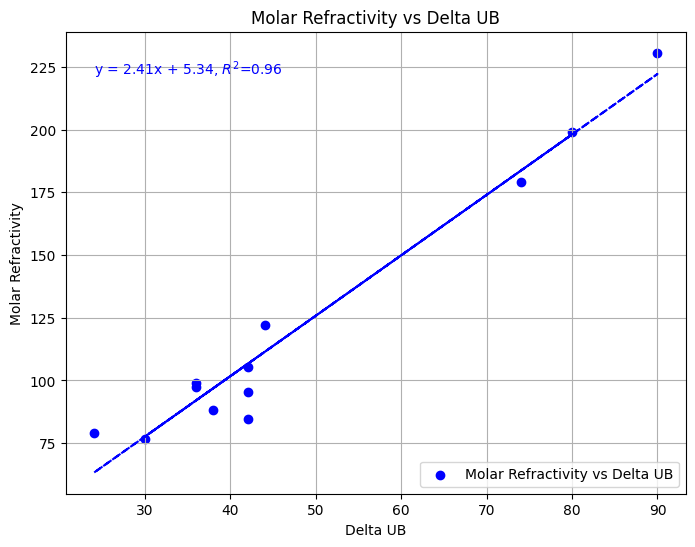

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_with_regression_y_on_top(x, y_dict, xlabel, ylabel, title):
    plt.figure(figsize=(8,6))
    x_vals = df[x].values.reshape(-1,1)
    
    colors = ['blue', 'red', 'green', 'orange']
    for i, (label, y) in enumerate(y_dict.items()):
        y_vals = df[y].values
        plt.scatter(df[x], y_vals, label=label, color=colors[i])
        
        # Linear regression (Y = f(X))
        model = LinearRegression()
        model.fit(x_vals, y_vals)
        y_pred = model.predict(x_vals)
        r2 = model.score(x_vals, y_vals)
        eq = f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}, $R^2$={r2:.2f}'
        
        # Plot regression line
        plt.plot(df[x], y_pred, linestyle='--', color=colors[i])
        # Annotate equation
        plt.text(df[x].min(), y_pred.max()-5*i, eq, color=colors[i])
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot 1: Molar Refractivity (Y) vs Lower and Upper Bound (X)
plot_with_regression_y_on_top(
    x='Lower_bound',
    y_dict={'Molar Refractivity vs Lower Bound': 'Molar_refractivity'},
    xlabel='Lower Bound',
    ylabel='Molar Refractivity',
    title='Molar Refractivity vs Lower Bound'
)

plot_with_regression_y_on_top(
    x='Upper_bound',
    y_dict={'Molar Refractivity vs Upper Bound': 'Molar_refractivity'},
    xlabel='Upper Bound',
    ylabel='Molar Refractivity',
    title='Molar Refractivity vs Upper Bound'
)

# Plot 2: Molar Refractivity (Y) vs Delta LB and Delta UB (X)
plot_with_regression_y_on_top(
    x='Delta_LB',
    y_dict={'Molar Refractivity vs Delta LB': 'Molar_refractivity'},
    xlabel='Delta LB',
    ylabel='Molar Refractivity',
    title='Molar Refractivity vs Delta LB'
)

plot_with_regression_y_on_top(
    x='Delta_UB',
    y_dict={'Molar Refractivity vs Delta UB': 'Molar_refractivity'},
    xlabel='Delta UB',
    ylabel='Molar Refractivity',
    title='Molar Refractivity vs Delta UB'
)


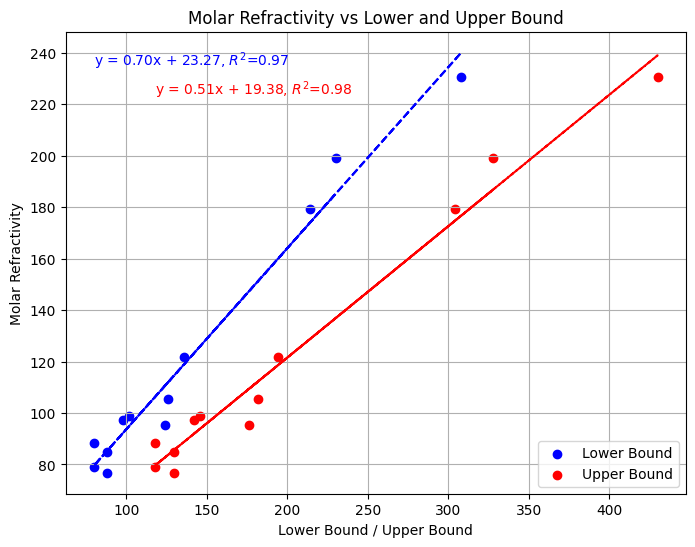

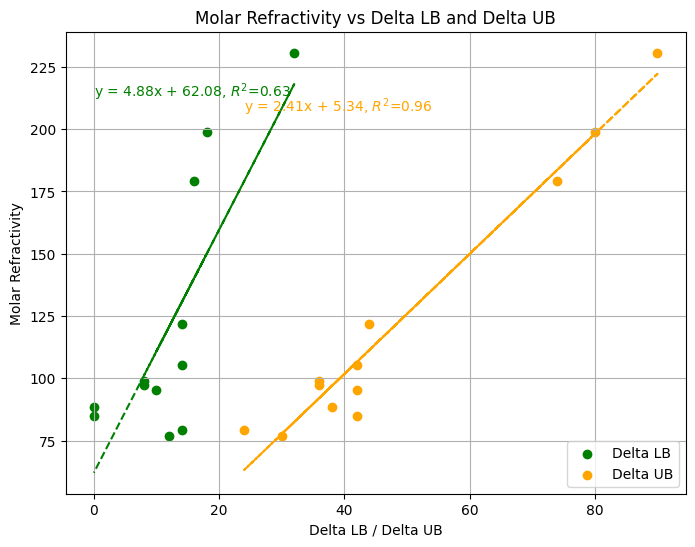

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_two_lines(x1, x2, y, xlabel1, xlabel2, ylabel, title, labels=('Line1','Line2'), colors=('blue','red')):
    plt.figure(figsize=(8,6))
    
    # First line
    x1_vals = df[x1].values.reshape(-1,1)
    y_vals = df[y].values
    plt.scatter(df[x1], y_vals, label=labels[0], color=colors[0])
    model1 = LinearRegression()
    model1.fit(x1_vals, y_vals)
    y_pred1 = model1.predict(x1_vals)
    r2_1 = model1.score(x1_vals, y_vals)
    eq1 = f'y = {model1.coef_[0]:.2f}x + {model1.intercept_:.2f}, $R^2$={r2_1:.2f}'
    plt.plot(df[x1], y_pred1, linestyle='--', color=colors[0])
    plt.text(df[x1].min(), y_pred1.max()-5, eq1, color=colors[0])
    
    # Second line
    x2_vals = df[x2].values.reshape(-1,1)
    plt.scatter(df[x2], y_vals, label=labels[1], color=colors[1])
    model2 = LinearRegression()
    model2.fit(x2_vals, y_vals)
    y_pred2 = model2.predict(x2_vals)
    r2_2 = model2.score(x2_vals, y_vals)
    eq2 = f'y = {model2.coef_[0]:.2f}x + {model2.intercept_:.2f}, $R^2$={r2_2:.2f}'
    plt.plot(df[x2], y_pred2, linestyle='--', color=colors[1])
    plt.text(df[x2].min(), y_pred2.max()-15, eq2, color=colors[1])
    
    plt.xlabel(f'{xlabel1} / {xlabel2}')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot 1: Lower & Upper Bound vs Molar Refractivity
plot_two_lines('Lower_bound', 'Upper_bound', 'Molar_refractivity',
               'Lower Bound', 'Upper Bound', 'Molar Refractivity',
               'Molar Refractivity vs Lower and Upper Bound',
               labels=('Lower Bound','Upper Bound'),
               colors=('blue','red'))

# Plot 2: Delta LB & Delta UB vs Molar Refractivity
plot_two_lines('Delta_LB', 'Delta_UB', 'Molar_refractivity',
               'Delta LB', 'Delta UB', 'Molar Refractivity',
               'Molar Refractivity vs Delta LB and Delta UB',
               labels=('Delta LB','Delta UB'),
               colors=('green','orange'))


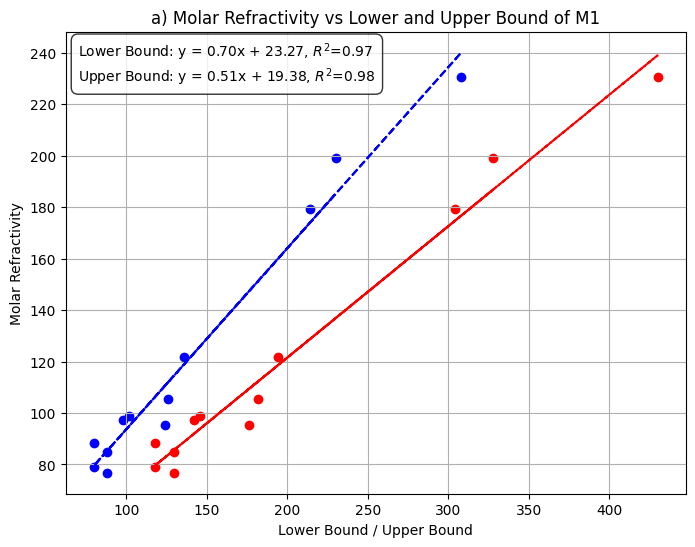

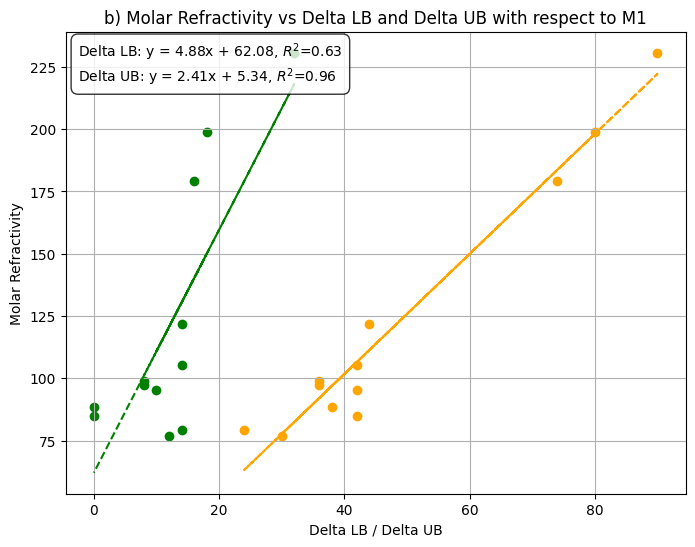

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_two_lines_boxed(x1, x2, y, xlabel1, xlabel2, ylabel, title, labels=('Line1','Line2'), colors=('blue','red')):
    plt.figure(figsize=(8,6))
    
    # First line
    x1_vals = df[x1].values.reshape(-1,1)
    y_vals = df[y].values
    plt.scatter(df[x1], y_vals, label=labels[0], color=colors[0])
    model1 = LinearRegression()
    model1.fit(x1_vals, y_vals)
    y_pred1 = model1.predict(x1_vals)
    r2_1 = model1.score(x1_vals, y_vals)
    eq1 = f'{labels[0]}: y = {model1.coef_[0]:.2f}x + {model1.intercept_:.2f}, $R^2$={r2_1:.2f}'
    plt.plot(df[x1], y_pred1, linestyle='--', color=colors[0])
    
    # Second line
    x2_vals = df[x2].values.reshape(-1,1)
    plt.scatter(df[x2], y_vals, label=labels[1], color=colors[1])
    model2 = LinearRegression()
    model2.fit(x2_vals, y_vals)
    y_pred2 = model2.predict(x2_vals)
    r2_2 = model2.score(x2_vals, y_vals)
    eq2 = f'{labels[1]}: y = {model2.coef_[0]:.2f}x + {model2.intercept_:.2f}, $R^2$={r2_2:.2f}'
    plt.plot(df[x2], y_pred2, linestyle='--', color=colors[1])
    
    # Place equations inside a box
    plt.text(0.02, 0.98, eq1 + '\n' + eq2, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8))
    
    plt.xlabel(f'{xlabel1} / {xlabel2}')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

# Plot 1: Lower & Upper Bound vs Molar Refractivity
plot_two_lines_boxed('Lower_bound', 'Upper_bound', 'Molar_refractivity',
                     'Lower Bound', 'Upper Bound', 'Molar Refractivity',
                     'a) Molar Refractivity vs Lower and Upper Bound of M1',
                     labels=('Lower Bound','Upper Bound'),
                     colors=('blue','red'))

# Plot 2: Delta LB & Delta UB vs Molar Refractivity
plot_two_lines_boxed('Delta_LB', 'Delta_UB', 'Molar_refractivity',
                     'Delta LB', 'Delta UB', 'Molar Refractivity',
                     'b) Molar Refractivity vs Delta LB and Delta UB with respect to M1',
                     labels=('Delta LB','Delta UB'),
                     colors=('green','orange'))


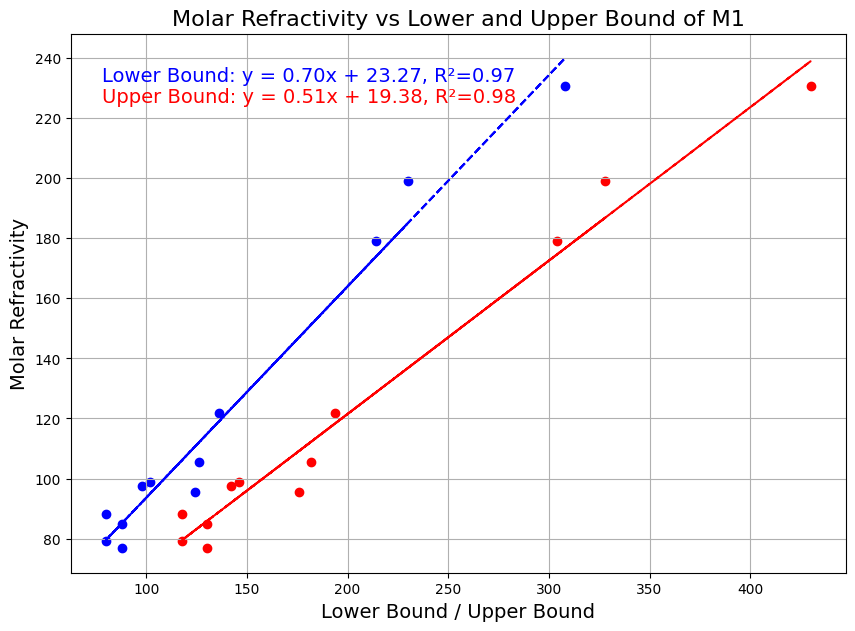

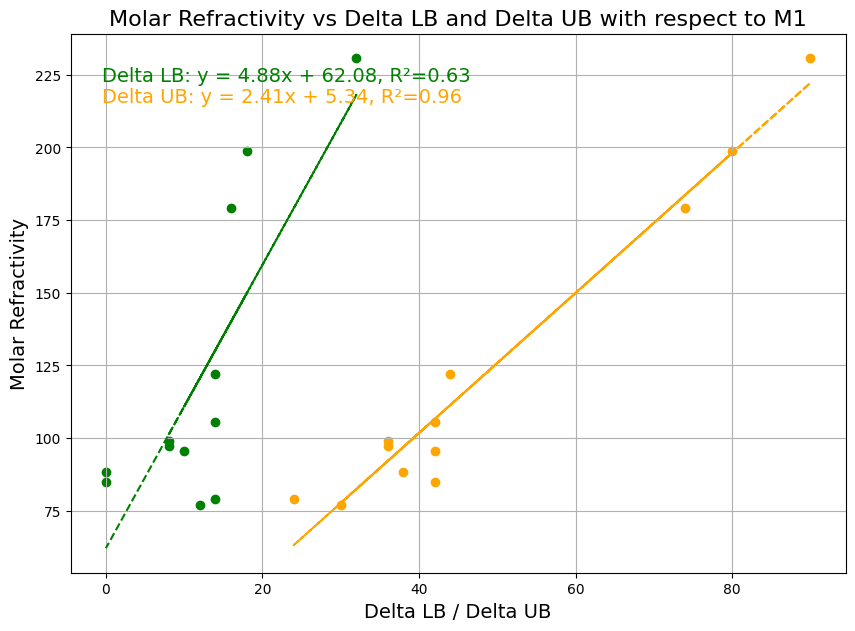

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_two_lines_boxed_colored(x1, x2, y, xlabel1, xlabel2, ylabel, title,
                                 labels=('Line1','Line2'), colors=('blue','red'), fontsize=14):
    plt.figure(figsize=(10,7))
    
    # First line
    x1_vals = df[x1].values.reshape(-1,1)
    y_vals = df[y].values
    plt.scatter(df[x1], y_vals, label=labels[0], color=colors[0])
    model1 = LinearRegression()
    model1.fit(x1_vals, y_vals)
    y_pred1 = model1.predict(x1_vals)
    r2_1 = model1.score(x1_vals, y_vals)
    eq1 = f'{labels[0]}: y = {model1.coef_[0]:.2f}x + {model1.intercept_:.2f}, R²={r2_1:.2f}'
    plt.plot(df[x1], y_pred1, linestyle='--', color=colors[0])
    
    # Second line
    x2_vals = df[x2].values.reshape(-1,1)
    plt.scatter(df[x2], y_vals, label=labels[1], color=colors[1])
    model2 = LinearRegression()
    model2.fit(x2_vals, y_vals)
    y_pred2 = model2.predict(x2_vals)
    r2_2 = model2.score(x2_vals, y_vals)
    eq2 = f'{labels[1]}: y = {model2.coef_[0]:.2f}x + {model2.intercept_:.2f}, R²={r2_2:.2f}'
    plt.plot(df[x2], y_pred2, linestyle='--', color=colors[1])
    
    # Place equations inside a box
    plt.text(0.02, 0.98, '', transform=plt.gca().transAxes,
             fontsize=fontsize, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='black', alpha=0.8))
    
    # Overlay colored text for each equation
    plt.text(0.04, 0.94, eq1, transform=plt.gca().transAxes, fontsize=fontsize, verticalalignment='top', color=colors[0])
    plt.text(0.04, 0.90, eq2, transform=plt.gca().transAxes, fontsize=fontsize, verticalalignment='top', color=colors[1])
    
    plt.xlabel(f'{xlabel1} / {xlabel2}', fontsize=fontsize)
    plt.ylabel(ylabel, fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2)
    plt.grid(True)
    plt.show()

# Plot 1: Lower & Upper Bound vs Molar Refractivity
plot_two_lines_boxed_colored('Lower_bound', 'Upper_bound', 'Molar_refractivity',
                             'Lower Bound', 'Upper Bound', 'Molar Refractivity',
                             'Molar Refractivity vs Lower and Upper Bound of M1',
                             labels=('Lower Bound','Upper Bound'),
                             colors=('blue','red'),
                             fontsize=14)

# Plot 2: Delta LB & Delta UB vs Molar Refractivity
plot_two_lines_boxed_colored('Delta_LB', 'Delta_UB', 'Molar_refractivity',
                             'Delta LB', 'Delta UB', 'Molar Refractivity',
                             'Molar Refractivity vs Delta LB and Delta UB with respect to M1',
                             labels=('Delta LB','Delta UB'),
                             colors=('green','orange'),
                             fontsize=14)


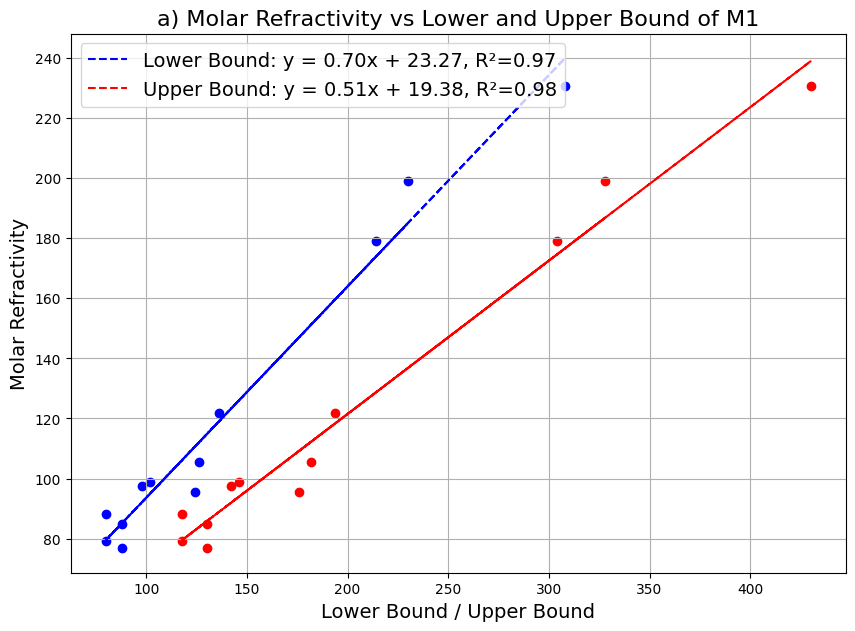

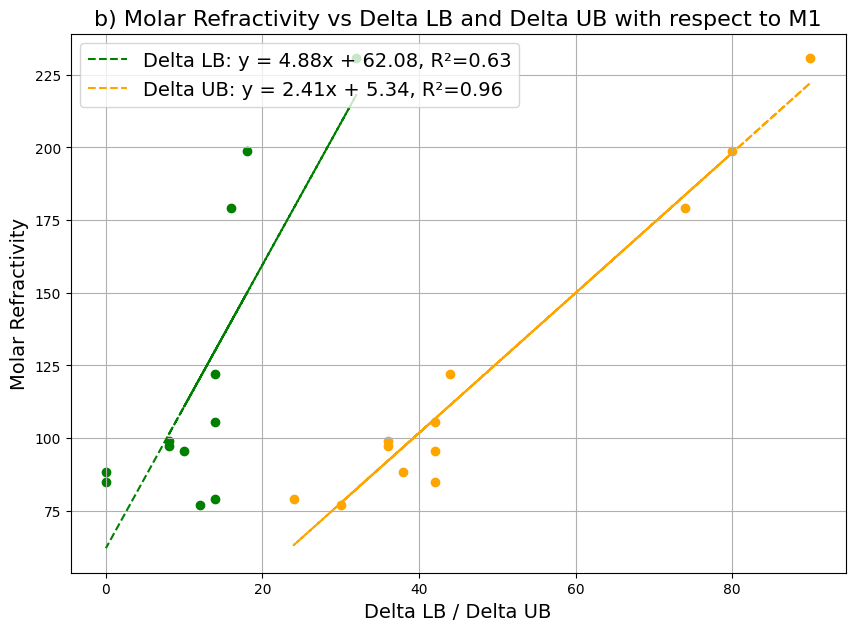

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_two_lines_legend_box(x1, x2, y, xlabel1, xlabel2, ylabel, title,
                              labels=('Line1','Line2'), colors=('blue','red'), fontsize=14):
    plt.figure(figsize=(10,7))
    
    y_vals = df[y].values
    
    # First line
    x1_vals = df[x1].values.reshape(-1,1)
    plt.scatter(df[x1], y_vals, color=colors[0])
    model1 = LinearRegression()
    model1.fit(x1_vals, y_vals)
    y_pred1 = model1.predict(x1_vals)
    r2_1 = model1.score(x1_vals, y_vals)
    eq1 = f'{labels[0]}: y = {model1.coef_[0]:.2f}x + {model1.intercept_:.2f}, R²={r2_1:.2f}'
    line1, = plt.plot(df[x1], y_pred1, linestyle='--', color=colors[0])
    
    # Second line
    x2_vals = df[x2].values.reshape(-1,1)
    plt.scatter(df[x2], y_vals, color=colors[1])
    model2 = LinearRegression()
    model2.fit(x2_vals, y_vals)
    y_pred2 = model2.predict(x2_vals)
    r2_2 = model2.score(x2_vals, y_vals)
    eq2 = f'{labels[1]}: y = {model2.coef_[0]:.2f}x + {model2.intercept_:.2f}, R²={r2_2:.2f}'
    line2, = plt.plot(df[x2], y_pred2, linestyle='--', color=colors[1])
    
    # Legend with equations inside the plot (boxed)
    plt.legend([line1, line2], [eq1, eq2], loc='upper left', fontsize=fontsize,
               frameon=True, fancybox=True, framealpha=0.8)
    
    plt.xlabel(f'{xlabel1} / {xlabel2}', fontsize=fontsize)
    plt.ylabel(ylabel, fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2)
    plt.grid(True)
    plt.show()

# Plot 1: Lower & Upper Bound vs Molar Refractivity
plot_two_lines_legend_box('Lower_bound', 'Upper_bound', 'Molar_refractivity',
                          'Lower Bound', 'Upper Bound', 'Molar Refractivity',
                          'a) Molar Refractivity vs Lower and Upper Bound of M1',
                          labels=('Lower Bound','Upper Bound'),
                          colors=('blue','red'),
                          fontsize=14)

# Plot 2: Delta LB & Delta UB vs Molar Refractivity
plot_two_lines_legend_box('Delta_LB', 'Delta_UB', 'Molar_refractivity',
                          'Delta LB', 'Delta UB', 'Molar Refractivity',
                          'b) Molar Refractivity vs Delta LB and Delta UB with respect to M1',
                          labels=('Delta LB','Delta UB'),
                          colors=('green','orange'),
                          fontsize=14)


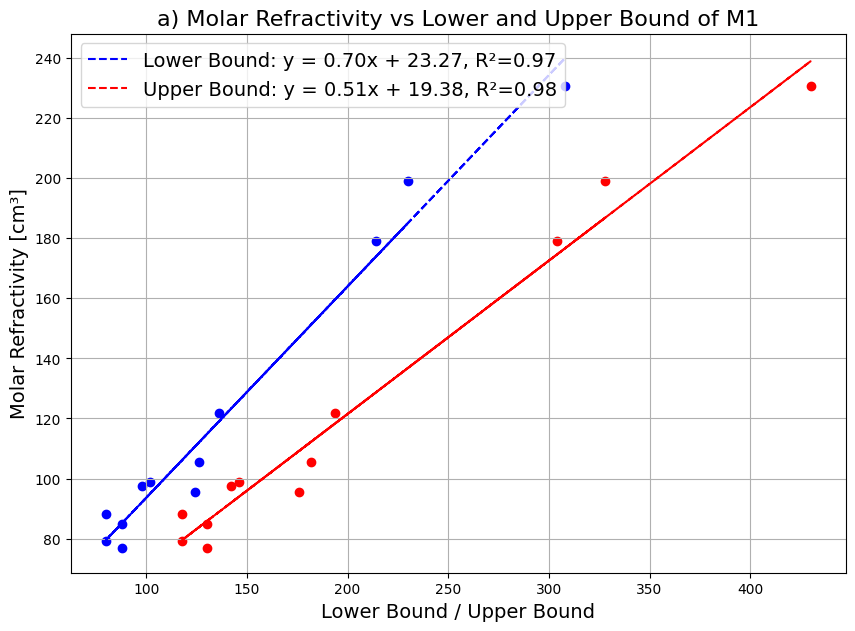

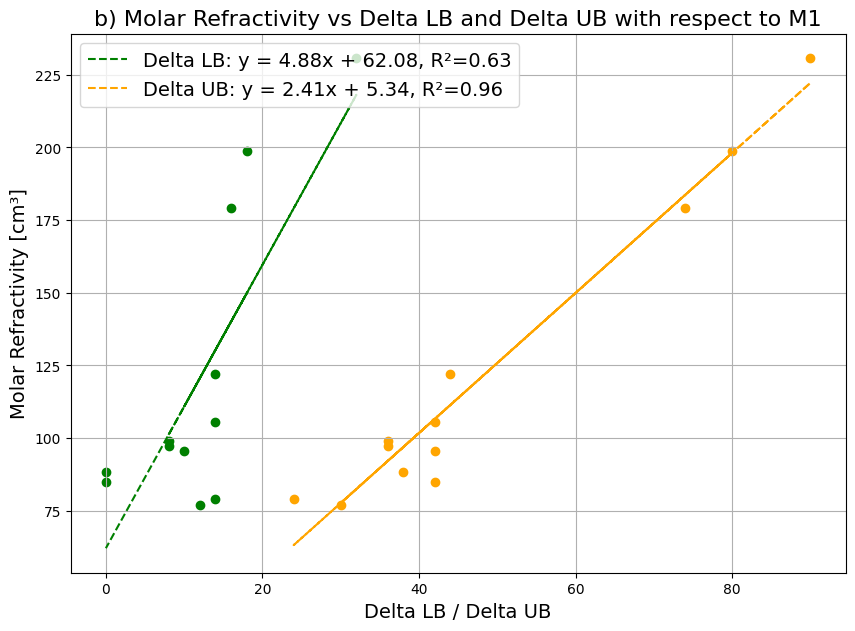

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
data = {
    'Drug': ['Chloroquine', 'Hydroxychloroquine', 'Lopinavir', 'Ritonavir', 'Nafamostat', 'Camostat',
             'Famotidine', 'Umifenovir', 'Ivermectin', 'Fluvoxamine', 'Cycloicosadecaene', 'Cyclodocosaundecaene'],
    'Lower_bound': [98, 102, 214, 230, 124, 126, 80, 136, 308, 88, 80, 88],
    'Upper_bound': [142, 146, 304, 328, 176, 182, 118, 194, 430, 130, 118, 130],
    'Delta_LB': [8, 8, 16, 18, 10, 14, 14, 14, 32, 12, 0, 0],
    'Delta_UB': [36, 36, 74, 80, 42, 42, 24, 44, 90, 30, 38, 42],
    'Molar_refractivity': [97.4, 99.0, 179.2, 198.9, 95.4, 105.4, 79.1, 121.9, 230.7, 76.8, 88.3, 84.8]
}

df = pd.DataFrame(data)

def plot_two_lines_legend_box_cm3(x1, x2, y, xlabel1, xlabel2, title,
                                  labels=('Line1','Line2'), colors=('blue','red'), fontsize=14):
    plt.figure(figsize=(10,7))
    
    y_vals = df[y].values
    
    # First line
    x1_vals = df[x1].values.reshape(-1,1)
    plt.scatter(df[x1], y_vals, color=colors[0])
    model1 = LinearRegression()
    model1.fit(x1_vals, y_vals)
    y_pred1 = model1.predict(x1_vals)
    r2_1 = model1.score(x1_vals, y_vals)
    eq1 = f'{labels[0]}: y = {model1.coef_[0]:.2f}x + {model1.intercept_:.2f}, R²={r2_1:.2f}'
    line1, = plt.plot(df[x1], y_pred1, linestyle='--', color=colors[0])
    
    # Second line
    x2_vals = df[x2].values.reshape(-1,1)
    plt.scatter(df[x2], y_vals, color=colors[1])
    model2 = LinearRegression()
    model2.fit(x2_vals, y_vals)
    y_pred2 = model2.predict(x2_vals)
    r2_2 = model2.score(x2_vals, y_vals)
    eq2 = f'{labels[1]}: y = {model2.coef_[0]:.2f}x + {model2.intercept_:.2f}, R²={r2_2:.2f}'
    line2, = plt.plot(df[x2], y_pred2, linestyle='--', color=colors[1])
    
    # Legend with equations inside the plot (boxed)
    plt.legend([line1, line2], [eq1, eq2], loc='upper left', fontsize=fontsize,
               frameon=True, fancybox=True, framealpha=0.8)
    
    plt.xlabel(f'{xlabel1} / {xlabel2}', fontsize=fontsize)
    plt.ylabel('Molar Refractivity [cm³]', fontsize=fontsize)  # Added units
    plt.title(title, fontsize=fontsize+2)
    plt.grid(True)
    plt.show()

# Plot 1: Lower & Upper Bound vs Molar Refractivity
plot_two_lines_legend_box_cm3('Lower_bound', 'Upper_bound',
                              'Molar_refractivity',
                              'Lower Bound', 'Upper Bound',
                              'a) Molar Refractivity vs Lower and Upper Bound of M1',
                              labels=('Lower Bound','Upper Bound'),
                              colors=('blue','red'),
                              fontsize=14)

# Plot 2: Delta LB & Delta UB vs Molar Refractivity
plot_two_lines_legend_box_cm3('Delta_LB', 'Delta_UB',
                              'Molar_refractivity',
                              'Delta LB', 'Delta UB',
                              'b) Molar Refractivity vs Delta LB and Delta UB with respect to M1',
                              labels=('Delta LB','Delta UB'),
                              colors=('green','orange'),
                              fontsize=14)
